# Simple Historical Value-at-Risk (VaR)

This notebook demonstrates a basic Historical VaR calculation for a single asset portfolio.

Included:
- Import pre-downloaded markets data, sourced from `yfinance`
- Compute log returns
- Calculate the 95% Historical VaR
- Plot the return distribution with the VaR cutoff

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from src.var_methods import historical_var

## Load Data

The data is loaded and the head displayed to verify formatting, in this case there are four ETFs

In [ ]:
data = pd.read_csv("../data/sample_prices.csv", index_col=0, parse_dates=[0], dayfirst=False) 
log_returns = np.log(data / data.shift(1)).dropna()

log_returns.head()

C:\Users\mw\AppData\Local\Temp\ipykernel_41140\127001477.py:1: UserWarning: Parsing dates in DD/MM/YYYY format when dayfirst=False (the default) was specified. This may lead to inconsistently parsed dates! Specify a format to ensure consistent parsing.
  data = pd.read_csv("../data/sample_prices.csv", index_col=0, parse_dates=[0], infer_datetime_format=True)


,BND,GLD,QQQ,SPY
Date,,,,
2020-03-01,0.003566,0.013181,-0.009202,-0.007601
2020-06-01,-0.001187,0.010435,0.006423,0.003808
2020-07-01,-0.000832,0.003927,-0.000139,-0.002816
2020-08-01,-0.001547,-0.007530,0.007488,0.005315
2020-09-01,0.001190,-0.005668,0.008438,0.006758


## Calculate Historical VaR

Assume a portfolio value of **$1,000,000** and calculate the **95% Historical VaR** over a 1-day horizon. In this example for a purely SPY portfolio.

In [27]:
weights = np.array([1])
portfolio_value = 1_000_000
alpha = 0.05

hist_var = historical_var(log_returns["SPY"], alpha=alpha, portfolio_value=portfolio_value, weights=weights)
print("Historical 95% 1-day VaR: " + "$" + str(int(hist_var)))

Historical 95% 1-day VaR: $19441


## Plot Return Distribution with VaR Cutoff

Example plot with returns given in log scale rather than dollar value.

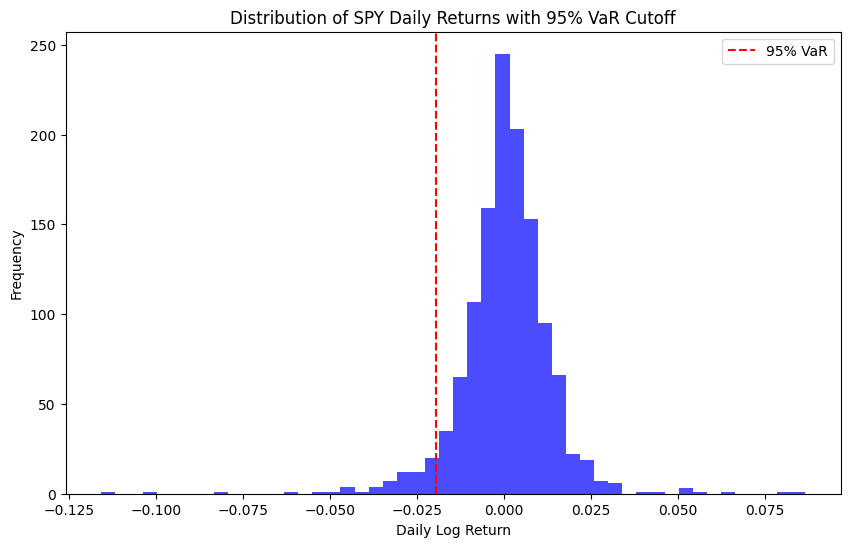

In [29]:
plt.figure(figsize=(10,6))
plt.hist(log_returns["SPY"], bins=50, alpha=0.7, color="blue")
plt.axvline(-hist_var/portfolio_value, color="red", linestyle="--", label="95% VaR")
plt.title("Distribution of SPY Daily Returns with 95% VaR Cutoff")
plt.xlabel("Daily Log Return")
plt.ylabel("Frequency")
plt.legend()
plt.show()

## Summary

- Calculated the 95% Historical VaR using past SPY returns.
- This gives the minimum expected loss on 5% of days, at a $1,000,000 portfolio value.
- Next: extending to Parametric VaR and Monte Carlo VaR (see later notebooks).